In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [2]:
PROJECT_ROOT = Path.cwd().parent   # assumes notebook lives in notebooks/, project root is one level up
OUTPUT_DIR = PROJECT_ROOT / "output" 
DATA_DIR = PROJECT_ROOT / "data" / "processed"
RAW_DATA_PATH = DATA_DIR / "customer_personality_cleaned.csv"

df = pd.read_csv(RAW_DATA_PATH)

CLUSTER_FEATURES = [
    "Income", "MntWines", "MntFruits", "MntMeatProducts", "MntFishProducts",
    "MntSweetProducts", "MntGoldProds", "duration", "age", "children",
]

In [3]:
target_col = 'Accepted_Cmp'

In [4]:
accepted = df[df[target_col] == "Yes"].copy()
scaler = StandardScaler()
scaled = scaler.fit_transform(accepted[CLUSTER_FEATURES])
km = KMeans(n_clusters=3, n_init=100, random_state=1234)
accepted["cluster"] = km.fit_predict(scaled)


c:\Users\lsmith3\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


### Plot Elbow

In [5]:
max_k = 10

c:\Users\lsmith3\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\lsmith3\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\lsmith3\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\lsmith3\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:14

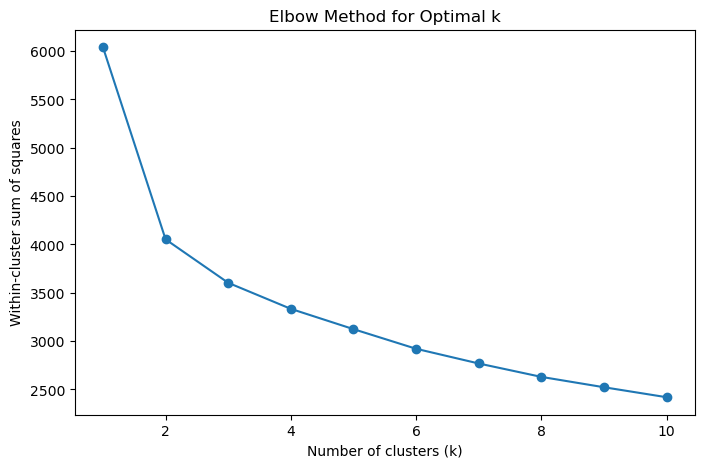

In [6]:
inertias = []
for k in range(1, max_k + 1):
    km = KMeans(n_clusters=k, n_init=100, random_state=1234)
    km.fit(scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, max_k + 1), inertias, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Within-cluster sum of squares")
plt.title("Elbow Method for Optimal k")
if True:
    OUTPUT_DIR.mkdir(exist_ok=True)
    plt.savefig(OUTPUT_DIR / "elbow_plot.png", dpi=150, bbox_inches="tight")
plt.show()

### Profile Plot

In [7]:
clustered_df = accepted
features = CLUSTER_FEATURES

In [8]:
standardized = pd.DataFrame(
    scaler.fit_transform(clustered_df[features]), columns=features, index=clustered_df.index
    )
standardized["cluster"] = clustered_df["cluster"].values

profile = standardized.groupby("cluster").mean().T


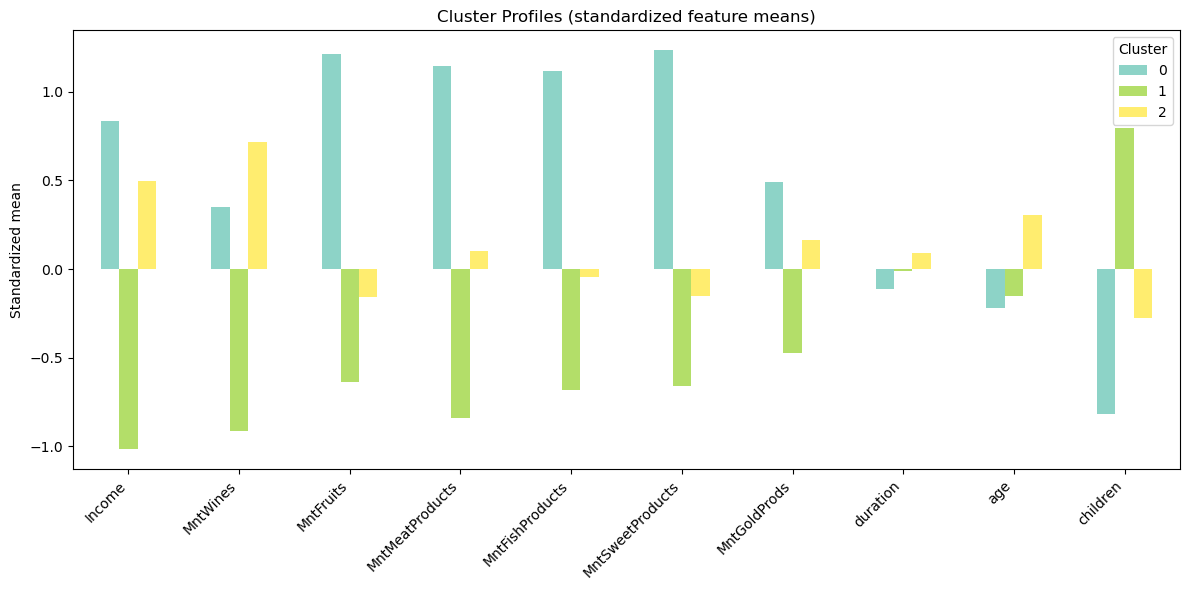

In [9]:
profile.plot(kind="bar", figsize=(12, 6), colormap="Set3")
plt.title("Cluster Profiles (standardized feature means)")
plt.ylabel("Standardized mean")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Cluster")
plt.tight_layout()
if True:
    OUTPUT_DIR.mkdir(exist_ok=True)
    plt.savefig(OUTPUT_DIR / 'cluster_profile.png', dpi=150, bbox_inches="tight")
plt.show()


Which clusters are most likely to accept a campaign

In [10]:
scaler = StandardScaler()
scaled_full = scaler.fit_transform(df[CLUSTER_FEATURES])
km = KMeans(n_clusters=3, n_init=100, random_state=1234)
df["cluster"] = km.fit_predict(scaled_full)

df.groupby("cluster")['Accepted_Cmp'].apply(lambda x: (x == "Yes").mean())


cluster
0    0.446247
1    0.157986
2    0.356261
Name: Accepted_Cmp, dtype: float64

The cell output above tells us how likely the members of each cluster is to accept a campaign. With Cluster 0 having the highest acceptance rate of 44.6%, followed by Cluster 2 by 35.6%, while Cluster 1 has the lowest at 15.8%. This means there is a real difference in how each cluster accepts a campaign as someone in Cluster 0 is almost 3 times as likely to accept a campaign compared to someone in Cluster 1.

In [11]:
df.to_csv(DATA_DIR / "customer_personality_with_clusters.csv", index=False)

In [12]:
df_cluster_campaign_prediction = pd.read_csv(DATA_DIR / "customer_personality_with_clusters.csv")

In [13]:
df_cluster_campaign_prediction.head(5)

,Education,Marital_Status,Income,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,...,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,age,Accepted_Cmp,duration,children,HighestPurchaseSource,cluster
0,College Graduate,Single,58138.0,635,88,546,172,88,88,3,...,10,4,7,0,66,Yes,14.047912,0,catalog,0
1,College Graduate,Single,46344.0,11,1,6,2,1,6,2,...,1,2,5,0,69,No,12.542094,2,store,1
2,College Graduate,Together,71613.0,426,49,127,111,21,42,1,...,2,10,4,0,58,No,13.086927,0,store,2
3,College Graduate,Together,26646.0,11,4,20,10,3,5,2,...,0,4,6,0,39,No,12.613279,1,store,1
4,PhD,Married,58293.0,173,43,118,46,27,15,5,...,3,6,5,0,42,No,12.673511,1,store,1
